 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Kevin O'Hagan    <br>
Student Number : L00196770       <br>
Due Date       : May 12th 2026   <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



In [ ]:
TODO!


# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs everything in the file, easier to list out there.
!pip install -r requirements.txt


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------- ---- 11.3/12.8 MB 86.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 79.4 MB/s  0:00:00


In [2]:
# Need to ensure to download the file to use it later on.
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### Note: must have Tesseract setup on local machine.

## Imports

In [2]:
# imports
import os
import matplotlib.pyplot as plt
import spacy
import nltk
import io
import pymupdf
import re
import cv2
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

import pytesseract
from pytesseract import Output

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt_tab')

# To run locally, update ath to your local tesseract executable file.
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [59]:
nlp = spacy.load("en_core_web_sm")

In [6]:
current_path = os.getcwd()
print(current_path)

C:\Users\User\Documents\ATUCourse\Artificial Intelligence for Vision and NLP\CA2\ca2-assignment-one-random-random-1


# Support Functions

In [50]:
## Setting config values to be used here
# Adding custom options for tesseract
# using the latest tesseract verion 5.0
tesseract_custom_config = r'--oem 1 --psm 4'  

In [60]:
# code here

## Helper to load/read in .pdf files
def convert_pdf_to_jpg(path, newfilename):
    doc = pymupdf.open(path)
    
    # if the pdf ad multiple pages this for loop can be edited to accommodate
    for page in doc:
        # setting the dpi to 200 for higher quality image - this can be set higher
        pix = page.get_pixmap(dpi=200)
        # Saving the image to local drive where it can be accessed again
        pix.save(f"{newfilename}.jpg")

## Helper to load/read in .jpg files

## Helper to grab all the text as string from image and return it
def initial_img_text(img, config):
    text = pytesseract.image_to_string(img, config=config)
    # print(text)
    return text

## Helper to import, and boxes and print
def initial_img_print_with_char_boxes(img):
    h, w, c = img.shape
    boxes = pytesseract.image_to_boxes(img)
    for b in boxes.splitlines():
        b = b.split(' ')
        img = cv2.rectangle(img, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.
    
    plt.imshow(img)
    plt.show()

## Helper to rotate imported items

## Helper to scale??

## Helper to compare results of one set of text to another, both provided as params (use for the utitlity bills comparison)



# NLP

## Sub Heading 1

C:\Users\User\Documents\ATUCourse\Artificial Intelligence for Vision and NLP\CA2\ca2-assignment-one-random-random-1\data\originals\photographed\utility_bill\utility_bill_page_1.jpg


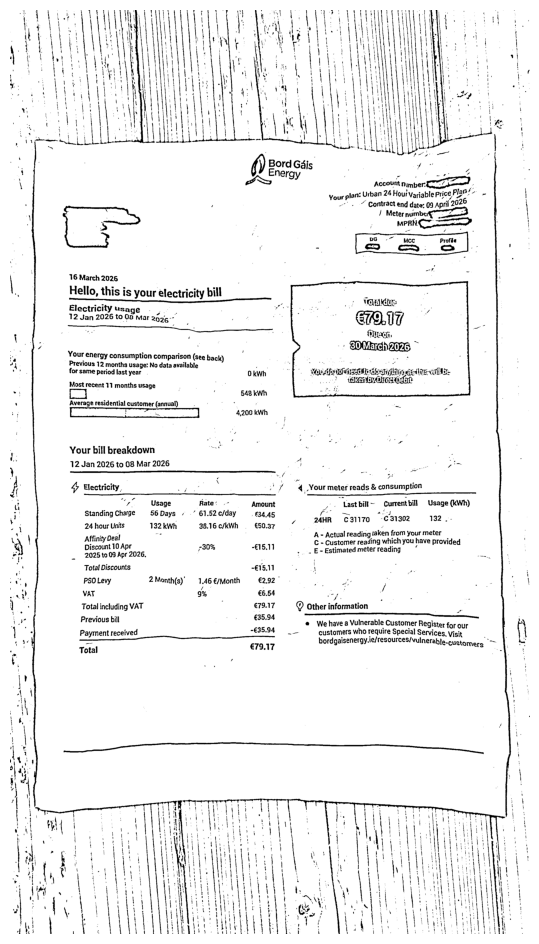

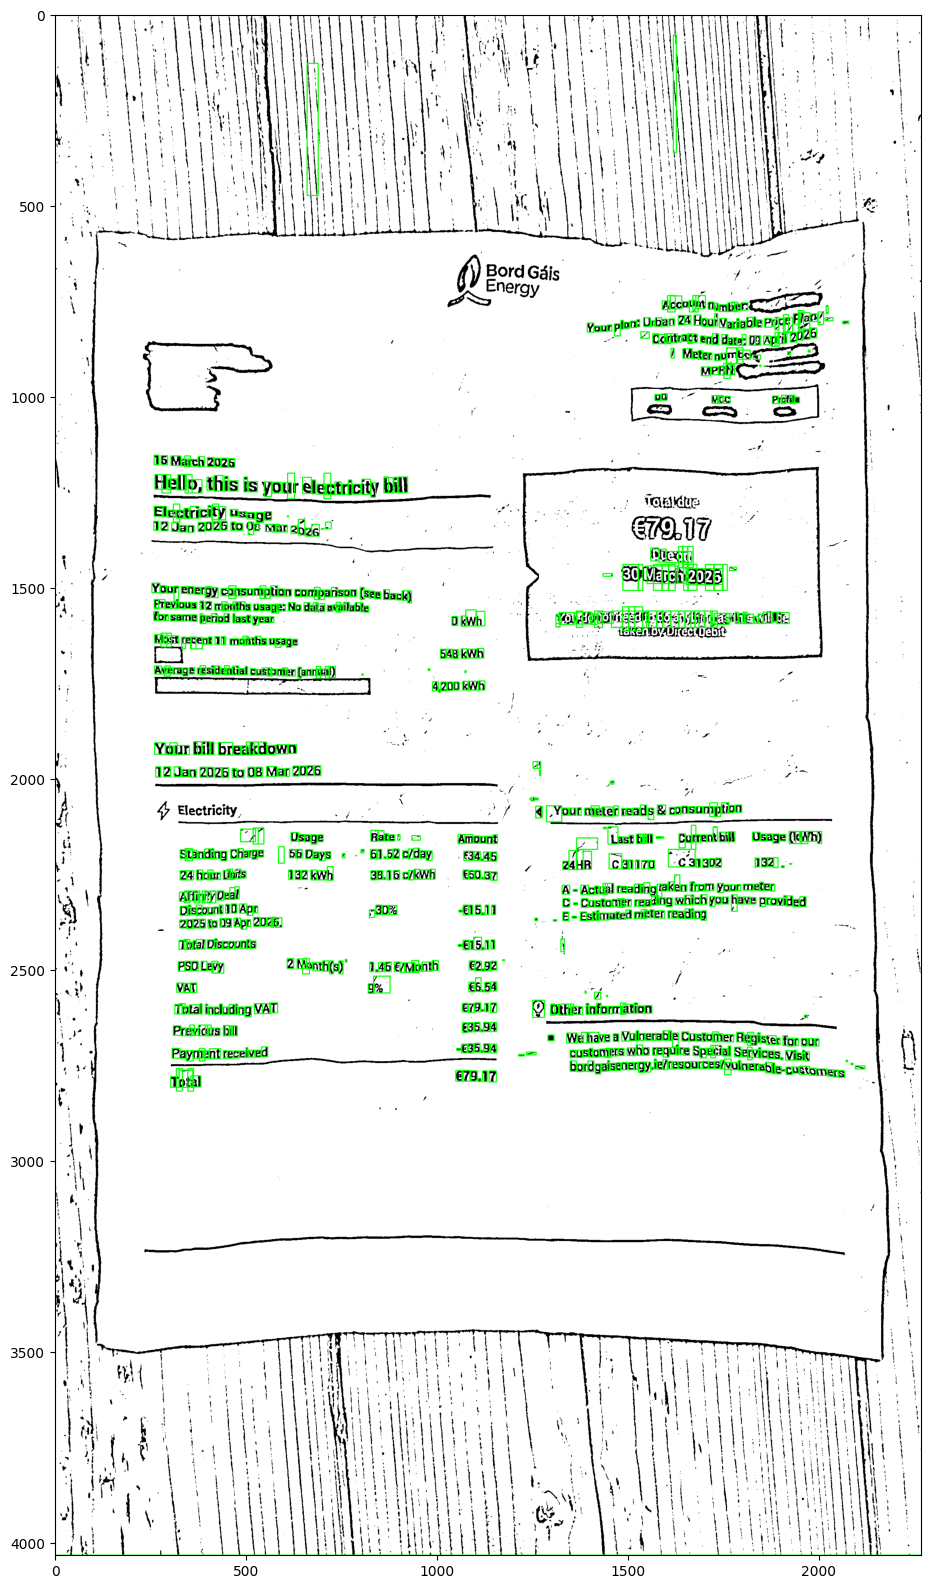

1                              CARDINAL                                        
7                              CARDINAL                                        
14                             CARDINAL                                        
4                              CARDINAL                                        
7                              CARDINAL                                        
1                              CARDINAL                                        
1 4%                           PERCENT      1 4%                               
Bord Gdis                      PERSON                                          
24 Hour                        TIME         :

Urban 24 Hour variable price    
09 April                       DATE         09 April

} Meter numbeQ™

eR

é

pe
Meter                          PERSON       09 April

} Meter numbeQ™

eR

é

pe
March 2026                     DATE                                            
7                              CARDINA

In [67]:
## code

# Setting global params for matplotlib
plt.rcParams['figure.figsize'] = (20, 20)

## Load up the image (eventually do it in some form of loop)
utility_bill_image_location = current_path + "\\data\\originals\\photographed\\utility_bill\\utility_bill_page_1.jpg"
print(utility_bill_image_location)
utility_bill_1_img = cv2.imread(utility_bill_image_location)
rotated_utility_bill_1_img = cv2.rotate(utility_bill_1_img,cv2.ROTATE_90_COUNTERCLOCKWISE)
# plt.imshow(rotated_utility_bill_1_img)
# plt.show()
utility_bill_1_img_rgb = cv2.cvtColor(rotated_utility_bill_1_img, cv2.COLOR_BGR2RGB)

# improve the image to get better text to display
gray_utility_bill_1 = cv2.cvtColor(rotated_utility_bill_1_img, cv2.COLOR_BGR2GRAY)

threshold_applied_utility_bill_1 = cv2.adaptiveThreshold(
    gray_utility_bill_1,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    11
)

plt.figure(figsize=(10, 12))
plt.imshow(threshold_applied_utility_bill_1, cmap="gray")
plt.axis("off")
plt.show()

initial_img_print_with_char_boxes(cv2.cvtColor(threshold_applied_utility_bill_1, cv2.COLOR_GRAY2BGR))
utility_bill_text = initial_img_text(threshold_applied_utility_bill_1, "--oem 3 --psm 11")

##TODO Need to improve the finding of text above ^^^^
## Look into maybe cropping different sections of the page that are not being recognised like th bill amount €79


## PDF comparison to see what is available in a cleaner version of the same file and compare the two
## Try out the .extract_text() function instead of the swap to image and then extracting
# newfilename = "pdfConvertedUtilityBill1"
# utility_bill_pdf_location = current_path + "\\data\\originals\\scanned\\utility_bill\\utilitybill.pdf"
# convert_pdf_to_jpg(utility_bill_pdf_location, newfilename)
# new_converted_file_location = f"{current_path}\\{newfilename}.jpg"
# converted_utility_bill = cv2.imread(new_converted_file_location)
# utility_bill_1_img_rgb = cv2.cvtColor(converted_utility_bill, cv2.COLOR_BGR2RGB)

# initial_img_print_with_char_boxes(utility_bill_1_img_rgb)
# initial_img_text(utility_bill_1_img_rgb, tesseract_custom_config)

## Extract the text from the image (first 1 then a loop for all) and store it in an array or dictionary.

## Review the text manually against the image, draw the boxes, play with param values to find the sweet spot for the image

## Tokenise the text, perform stemming and lemmatisation
nlp_utility_bill = nlp(utility_bill_text)
# for token in nlp_utility_bill:
#     print (token.text, token.pos_, end = " | ")
col1 = "Named Entity"
col2 = "Label"
col3 = "Noun Chunk"

sentance_noun_chunks = list(nlp_utility_bill.noun_chunks)

# Header
print(f"{col1:30} {col2:12} {col3:35}")
print("-" * 80)
for entity in nlp_utility_bill.ents:
    chunk_for_entity = None
    for chunk in sentance_noun_chunks:
        # Check if the entity is in the noun chunk
        if entity.start >= chunk.start and entity.end <= chunk.end:
            chunk_for_entity = chunk.text
            # breaking as will only be one instance
            break

    chunk_text = chunk_for_entity if chunk_for_entity is not None else ""
    print(f"{entity.text:30} {entity.label_:12} {chunk_text:35}")

## Figure out the meaningful parts using TF-IDF or Bag of Words and NER. (Sentiment analysis could be good for book or acedemic paper)

## Categorise the sections. For the instructions and acedemic paper could try figure out the link between steps aswell as links to images

## Potentially remove the stop words, but be aware this could impact the Parts of Speech work later

## Consider grouping into Topics but not sure on this one and if it should live in this section or be included at all.

# Vision

## Sub Heading 1

In [ ]:
# code here...

## Preprocess the image/s using OpenCV. With the coke zero and bills, block out the outside useless information. Rotate and resize images as needed.

## Find the features in the image, use edge detection (could be good for rice image with instructions)

## Split out the parts of the image into areas and identify them. Similar to first step here or maybe move fully to here like removal of backround
## noise/useless parts

## Try to improve the focus of the words/the important parts of the document. The book has some blurry text with the scanning so could be useful here

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

## Put together the image stuff with the text stuff to show an outcome/result for the document



# Final Output

In [ ]:
# code

In [ ]:
## Create the final output to compare the original image to the refined one. To compare the original read in text to the cleaned. And any
## of the analysis that was done.